<a href="https://colab.research.google.com/github/HIPPO1542/THDeepleaningg/blob/main/ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ==========================================
# 1. IMPORT THƯ VIỆN
# ==========================================

import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.utils import to_categorical

import matplotlib.pyplot as plt
import numpy as np

In [2]:
# ==========================================
# 2. ĐỌC DATASET FASHION MNIST
# ==========================================

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

print("Kích thước train:", x_train.shape)
print("Kích thước test:", x_test.shape)


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Kích thước train: (60000, 28, 28)
Kích thước test: (10000, 28, 28)


In [3]:
# ==========================================
# 3. XỬ LÝ DỮ LIỆU
# ==========================================

# Chuẩn hóa dữ liệu về khoảng [0,1]
x_train = x_train / 255.0
x_test = x_test / 255.0

# One-hot encoding label
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print("Shape y_train:", y_train.shape)

Shape y_train: (60000, 10)


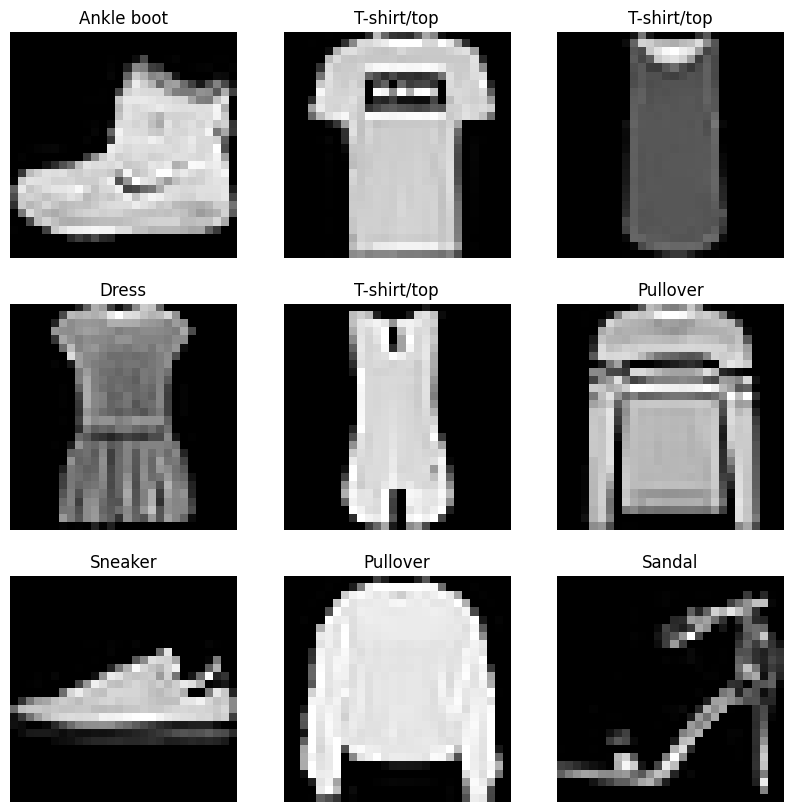

In [4]:
# ==========================================
# 4. TRỰC QUAN HÓA DỮ LIỆU
# ==========================================

class_names = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(class_names[np.argmax(y_train[i])])
    plt.axis('off')

plt.show()


In [5]:
# ==========================================
# 5. XÂY DỰNG MÔ HÌNH ANN
# ==========================================

model = Sequential()

# Chuyển ảnh 28x28 thành vector
model.add(Flatten(input_shape=(28,28)))

# Hidden layer 1
model.add(Dense(256, activation='relu'))

# Dropout chống overfitting
model.add(Dropout(0.3))

# Hidden layer 2
model.add(Dense(128, activation='relu'))

# Output layer
model.add(Dense(10, activation='softmax'))

# Hiển thị mô hình
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# ==========================================
# 6. COMPILE MODEL
# ==========================================

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [9]:
# ==========================================
# 7. HUẤN LUYỆN MODEL
# ==========================================

history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(x_test, y_test)
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8080 - loss: 0.5331 - val_accuracy: 0.8410 - val_loss: 0.4287
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8487 - loss: 0.4119 - val_accuracy: 0.8581 - val_loss: 0.3922
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8610 - loss: 0.3779 - val_accuracy: 0.8546 - val_loss: 0.4020
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8691 - loss: 0.3561 - val_accuracy: 0.8621 - val_loss: 0.3770
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8724 - loss: 0.3424 - val_accuracy: 0.8768 - val_loss: 0.3466
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8770 - loss: 0.3314 - val_accuracy: 0.8715 - val_loss: 0.3590
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8811 - loss: 0.3184 - val_accuracy: 0.8765 - val_loss: 0.3382
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8835 - loss: 0.3135 - 

In [11]:
# ==========================================
# 8. ĐÁNH GIÁ MODEL
# ==========================================

test_loss, test_acc = model.evaluate(x_test, y_test)

print("Độ chính xác trên tập test:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8770 - loss: 0.3405
Độ chính xác trên tập test: 0.8769999742507935


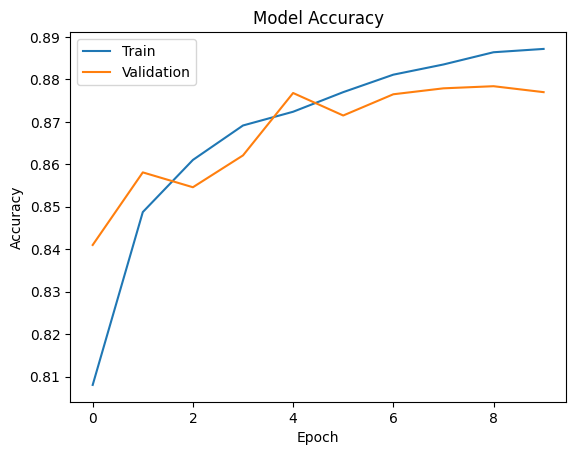

In [12]:
# ==========================================
# 9. VẼ BIỂU ĐỒ ACCURACY
# ==========================================

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

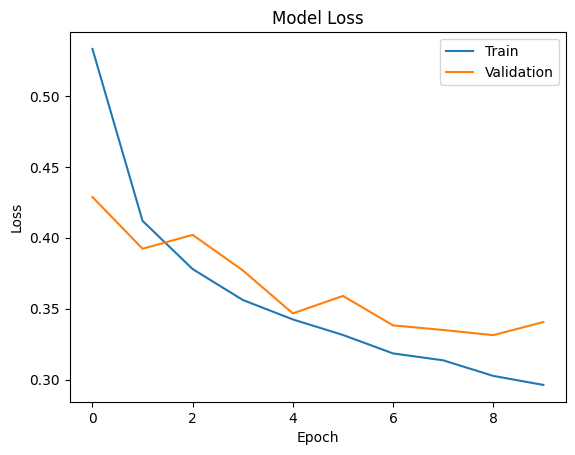

In [15]:
# ==========================================
# 9. VẼ BIỂU ĐỒ MODEL LOSS
# ==========================================
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


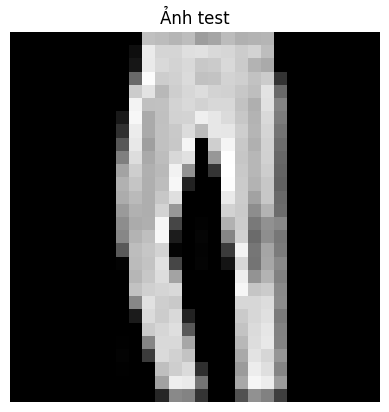

Dự đoán: Trouser
Nhãn thật: Trouser


In [13]:
# ==========================================
# 10. DỰ ĐOÁN ẢNH MỚI
# ==========================================

predictions = model.predict(x_test)

# Chọn ảnh bất kỳ
index = 5

plt.imshow(x_test[index], cmap='gray')
plt.title("Ảnh test")
plt.axis('off')
plt.show()

predicted_label = np.argmax(predictions[index])

print("Dự đoán:", class_names[predicted_label])
print("Nhãn thật:", class_names[np.argmax(y_test[index])])

In [14]:
# ==========================================
# 11. LƯU MODEL
# ==========================================

model.save("fashion_ann_model.h5")

print("Đã lưu model thành công")

Đã lưu model thành công
